# Results review, 2026-10-09: finished jobs since 2026-10-07

Every number below is computed in this notebook from the result file printed next to it. Each experiment is checked
against the prediction written in `experiments/ledger.jsonl` before it ran. Nothing here writes to the ledger.

| Section | Ledger entry | Jobs | Source |
|---|---|---|---|
| 1. Conditioning mechanism, N = 256 | `nf_condmech_n256` | 63381901 → 63381902 → 63381903 | `results/nf_conditioning_mechanism_n256/` |
| 2. Ωm-only vs (Ωm, σ8) label, N = 64, 256, 1024 | `nf_om_continuous_eval_n64_n256`, `nf_om_continuous_n1024_sample_eval` | 63397804 → 63414371; 63582414 → 63582416 | `results/nf_conditional_om_continuous_200k/calibration_vgg_n64_n256/`, `.../calibration_vgg_n1024/` |
| 3a. Augmentation sweep (main) | `unet128_aug_sweep_eval` (done, unsupported) | 63414529 → 63428813 | `results/unet128_aug_sweep/evaluate_run_v1/` |
| 3b. Checkpoint sweep | `unet128_aug_ckpt_sweep` | 63559649 → 63559651 | `results/unet128_aug_sweep/evaluate_run_ckpt_v1/` |
| 3c. Patch mosaic | `unet128_aug_patch_mosaic` | 63563565 | `results/unet128_aug_sweep/patch_mosaic_v1/` |

The full augmentation analysis (galleries, loss curves) is in `notebooks/unet128_aug_sweep_results.ipynb`.
Probe intervals are spreads over 64 generated maps per cosmology, not posteriors. One training seed per run.
Version 2 of `notebooks/results_review_20261009.ipynb`: same computations, clearer model descriptions.

## The conditional models compared in Sections 1 and 2

Every model here is the same 3-level UNet (channel widths 32 / 64 / 128 at resolutions 128×128 / 64×64 / 32×32, two ResNet
blocks per level, self-attention at the 32×32 level and in the middle block). Every model gets the same training maps at a
given N, has training seed 123 and 200k updates, and uses the same sampler (DPM-Solver, 50 steps), the same 32 held-out cosmologies
(simulations 900–931, 64 maps each) and the same frozen VGG regressor ("probe") to read Ωm back from the maps.
The label is the cosmology, z-scored. **The only thing that changes is how the label gets into the network.**

| Name in this notebook | Run name | Label | How the label enters | Which resolutions see the label |
|---|---|---|---|---|
| **Baseline: cross-attention** (this is the existing *continuous (Ωm, σ8)* model) | `nf_cond_omsigc_hi_u128_d2p08_n256_fresh200k` | (Ωm, σ8) | The 2-number label becomes **one token**. The feature maps attend to it with cross-attention. One token has no positions, so this acts as a learned, label-dependent shift of the features. | **32×32 level and middle block only.** The 128×128 and 64×64 levels never see the label. |
| **temb** (timestep-embedding, additive) | `nf_condmech_n256_temb` | (Ωm, σ8) | A small MLP maps the label to a vector that is **added to the timestep embedding**. Every ResNet block then adds a per-channel offset computed from that embedding, which is how diffusion UNets already tell blocks the noise level. | In principle all levels. But at 128×128 there are 32 channels in 32 GroupNorm groups, so each group is one channel and the next GroupNorm subtracts the offset back out. **Effectively only 64×64 (partly) and 32×32.** |
| **tembss** (timestep-embedding, scale-shift / FiLM) | `nf_condmech_n256_tembss` | (Ωm, σ8) | Same label MLP, but every ResNet block uses the embedding to **scale and shift the features after GroupNorm** (h → norm(h)·(1 + scale) + shift; the AdaGN / FiLM scheme of ADM and EDM). Nothing cancels it. | **Every level, 128×128 to 32×32.** |
| **tembss, no min-SNR** | `nf_condmech_n256_tembss_nosnr` | (Ωm, σ8) | Identical network to tembss, but trained **without min-SNR loss weighting**, so all noise levels count equally in the loss (min-SNR γ = 5 down-weights the low-noise steps in every other run). | Every level. |
| **Ωm-only** (Section 2) | `nf_cond_omc_hi_u128_d2p0X_nNNN_fresh200k` | Ωm only | Same cross-attention route as the baseline, but the token holds **only Ωm**. The model is never told σ8. | 32×32 level and middle block only. |

**Caveat: the three new models also change the architecture, not only the label route.** In the baseline, the 32×32 level and the
middle block are cross-attention *transformer* blocks (self-attention + cross-attention to the label token + a feed-forward MLP).
In temb / tembss these become plain self-attention blocks (no cross-attention, no feed-forward), and a label MLP is added.
So "where the label enters" is confounded with "which attention blocks the network has". The baseline was trained on 2026-09-30
and the new models on 2026-10-08/09; the cosmodiff code version used for each is not recorded.

Sections 1 and 2 share one run: **at N = 256 the cross-attention baseline in Section 1 *is* the continuous (Ωm, σ8) model in Section 2.**

Why test this (prediction written 2026-10-06, ledger `nf_condmech_n256`): the baseline injects the label only at coarse resolution.
Conditioning that reaches every resolution (tembss) was expected to give sharper maps, a P(k) closer to the real one and a smaller Ωm bias.

In [1]:
%matplotlib inline
from pathlib import Path
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_DIR = Path("/home/jiamingp/diffusion_models_repo")
for p in (str(PROJECT_DIR), str(PROJECT_DIR / "scripts")):
    if p not in sys.path:
        sys.path.insert(0, p)
from simdiff_eval import run_metrics as rm
from simdiff_eval.conditional_unet_diagnostics import nearest_centered_pixel_cosine, normalize_raw_hi
from simdiff_eval.probe_eval import load_heldout_real_slices
from prepare_nf_conditional_u128_config import DATA_ROOT
%matplotlib inline

W = rm.W_REAL_OMEGA_M          # 0.0931, probe 68% width on real held-out maps (docs/decisions.md, 2026-10-06)
HELDOUT = np.arange(900, 932)
LEVELS = np.unique(np.r_[np.linspace(0, 1, 101), 0.68, 0.95])
NORM = dict(np.load(PROJECT_DIR / "results/nf_conditional_bias_probe/encoder/vgg_mlp_encoder.npz", allow_pickle=True)["normalization"].item())
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
                     "figure.dpi": 110})
src = lambda p: print("source:", p)

def recovery(folder, run_name, params=("Omega_m", "sigma_8")):
    folder = PROJECT_DIR / folder
    pts = pd.read_csv(folder / "bias_probe_per_cosmology_points.csv")
    pts = pts[(pts.run_name == run_name) & (pts.guidance_label == "noguidance")]
    pred = pd.read_csv(folder / "bias_probe_per_sample_predictions.csv")
    pred = pred[(pred.run_name == run_name) & (pred.guidance_label == "noguidance")]
    assert set(pts.heldout_sim) == set(HELDOUT), (folder, run_name)
    out, curves = {}, {}
    for p in params:
        s = rm.recovery_summary(pts, p, W if p == "Omega_m" else None)
        d = pred[pred.parameter == p].sort_values(["heldout_sim", "seed_index"])
        draws = d.theta_rec.to_numpy().reshape(32, -1)
        truth = d.groupby("heldout_sim").theta_in.first().loc[HELDOUT].to_numpy()
        lo, hi = np.quantile(draws, (1 - LEVELS) / 2, axis=1), np.quantile(draws, (1 + LEVELS) / 2, axis=1)
        curve = ((lo <= truth) & (truth <= hi)).mean(1)
        s["covered95"] = int(round(curve[np.isclose(LEVELS, 0.95)][0] * 32))
        out.update({f"{p}_{k}": v for k, v in s.items()})
        curves[p] = curve
    return out, pts, curves

print("Loading real held-out slices (32 cosmologies x 128 slices) for the P(k) reference ...")
real, _, real_sim, _ = load_heldout_real_slices(DATA_ROOT, HELDOUT, 128, NORM)
real = rm.as_maps(real)
BIN = rm.pk_binning(128)
pk_real = rm.power_spectra(real, BIN)
real_mean = np.stack([pk_real[real_sim == s].mean(0) for s in HELDOUT])
split_half = np.stack([pk_real[real_sim == s][::2].mean(0) / pk_real[real_sim == s][1::2].mean(0) for s in HELDOUT])
REF_BANDS = {k: v for k, v in rm.pk_band_values(split_half, BIN).items() if not k.endswith("pct")}
print("real split-half P(k) bands (reference):", {k: round(v, 4) for k, v in REF_BANDS.items()})

def map_stats(sample_path, train_raw_path):
    with np.load(PROJECT_DIR / sample_path, allow_pickle=True) as z:
        gen = rm.as_maps(z["samples"]); k = int(z["samples_per_cosmology"])
        assert np.array_equal(z["heldout_indices"], HELDOUT)
    ratios = rm.power_spectra(gen, BIN).reshape(32, k, -1).mean(1) / real_mean
    out = {k_: v for k_, v in rm.pk_band_values(ratios, BIN).items() if not k_.endswith("pct")}
    train = normalize_raw_hi(np.load(train_raw_path, mmap_mode="r")[:, 0], NORM)
    cos, j = nearest_centered_pixel_cosine(gen, train)
    std_ratio = gen.reshape(len(gen), -1).std(1) / train.reshape(len(train), -1)[j].std(1)
    out.update(nearest_train_cosine_median=float(np.median(cos)), pix_std_ratio_median=float(np.median(std_ratio)),
               draw_to_draw_cosine_median=float(np.median([rm.draw_to_draw_cosine(gen[i*k:(i+1)*k])["mean"] for i in range(32)])))
    return out, ratios

Loading real held-out slices (32 cosmologies x 128 slices) for the P(k) reference ...
real split-half P(k) bands (reference): {'pk_large': 1.0004, 'pk_mid': 1.0004, 'pk_small': 1.0005}


## 1. Conditioning mechanism at N = 256

Four models from the table above, all at N = 256: **baseline (cross-attention, = the continuous (Ωm, σ8) run)**, **temb**, **tembss**,
**tembss without min-SNR**. Baseline results are read from `results/nf_conditional_omsig_continuous_200k/calibration_vgg/`;
the three new models from `results/nf_conditioning_mechanism_n256/calibration_vgg/`.

**Prediction (ledger, written 2026-10-06 before training):** conditioning at every resolution reduces smoothing of the copies
(pixel-std ratio from 0.95 toward ≥ 0.98), moves the P(k) bands from 0.82 / 0.82 / 0.94 toward 1 and reduces |Ωm bias|;
tembss best, temb weakest. **Decision rule:** adopt an arm if it improves Ωm bias and the P(k) bands with no band worse by more than 3%.

In [2]:
CM = json.loads((PROJECT_DIR / "local/nf_conditioning_mechanism_n256/manifest.json").read_text())
BASE = next(r for r in json.loads((PROJECT_DIR / "local/nf_conditional_omsig_continuous_200k/manifest.json").read_text())
            if r["dataset_size"] == 256)
NAMES = {"nf_condmech_n256_temb": "temb (added to timestep emb.)", "nf_condmech_n256_tembss": "tembss (scale-shift, all levels)",
         "nf_condmech_n256_tembss_nosnr": "tembss, no min-SNR"}
runs = [("baseline: cross-attention", "results/nf_conditional_omsig_continuous_200k/calibration_vgg", BASE)] + \
       [(NAMES[r["run_name"]], "results/nf_conditioning_mechanism_n256/calibration_vgg", r) for r in CM]
rows, pk_curves, cov_curves, pts_by = [], {}, {}, {}
for label, folder, row in runs:
    rec, pts, curves = recovery(folder, row["run_name"])
    ms, ratios = map_stats(row["sample_path"].format(seed=123, k=64), row["prepared_image_path"])
    rows.append(dict(arm=label, run_name=row["run_name"], **rec, **ms))
    pk_curves[label], cov_curves[label], pts_by[label] = ratios, curves, pts
    src(f"{folder}/bias_probe_per_cosmology_points.csv [{row['run_name']}]")
cm = pd.DataFrame(rows).set_index("arm")
show = ["Omega_m_median_bias", "Omega_m_median_bias_over_W", "Omega_m_covered68", "Omega_m_covered95", "Omega_m_median_width68",
        "sigma_8_median_bias", "sigma_8_covered68", "pk_large", "pk_mid", "pk_small", "pix_std_ratio_median",
        "nearest_train_cosine_median", "draw_to_draw_cosine_median"]
display(cm[show].T.round(4))

source: results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_cond_omsigc_hi_u128_d2p08_n256_fresh200k]
source: results/nf_conditioning_mechanism_n256/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_condmech_n256_temb]
source: results/nf_conditioning_mechanism_n256/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_condmech_n256_tembss]
source: results/nf_conditioning_mechanism_n256/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_condmech_n256_tembss_nosnr]


arm,baseline: cross-attention,temb (added to timestep emb.),"tembss (scale-shift, all levels)","tembss, no min-SNR"
Omega_m_median_bias,-0.0344,-0.0423,-0.0411,-0.1407
Omega_m_median_bias_over_W,-0.3694,-0.4546,-0.4410,-1.5111
Omega_m_covered68,13.0000,9.0000,11.0000,2.0000
Omega_m_covered95,18.0000,18.0000,17.0000,5.0000
Omega_m_median_width68,0.0519,0.0629,0.0429,0.0832
sigma_8_median_bias,0.0039,-0.0205,-0.0229,-0.0401
sigma_8_covered68,9.0000,6.0000,6.0000,10.0000
pk_large,0.8198,0.7097,0.7427,0.6108
pk_mid,0.8183,0.7138,0.7483,0.4383
pk_small,0.9449,0.9684,0.6965,0.6754


In [3]:
b = cm.loc["baseline: cross-attention"]
dec = []
for arm, r in cm.drop(index="baseline: cross-attention").iterrows():
    bias_better = abs(r.Omega_m_median_bias) < abs(b.Omega_m_median_bias)
    worse = {band: (abs(r[f"pk_{band}"] - 1) - abs(b[f"pk_{band}"] - 1)) for band in ("large", "mid", "small")}
    improved = {band: d < 0 for band, d in worse.items()}
    no_band_worse_3pct = all(d <= 0.03 for d in worse.values())
    dec.append(dict(arm=arm, abs_bias_better=bias_better, bands_closer_to_1=sum(improved.values()),
                    worst_band_change=max(worse.values()), no_band_worse_than_3pct=no_band_worse_3pct,
                    pix_std_ratio_ge_0p98=r.pix_std_ratio_median >= 0.98,
                    ADOPT=bias_better and all(improved.values()) and no_band_worse_3pct))
dec = pd.DataFrame(dec).set_index("arm")
display(dec.round(4))
print("Decision rule from ledger nf_condmech_n256. 'worst_band_change' = max over bands of |arm-1| - |baseline-1| (positive = worse).")

,abs_bias_better,bands_closer_to_1,worst_band_change,no_band_worse_than_3pct,pix_std_ratio_ge_0p98,ADOPT
arm,,,,,,
temb (added to timestep emb.),False,1,0.1101,False,False,False
"tembss (scale-shift, all levels)",False,0,0.2484,False,False,False
"tembss, no min-SNR",False,0,0.3800,False,False,False


Decision rule from ledger nf_condmech_n256. 'worst_band_change' = max over bands of |arm-1| - |baseline-1| (positive = worse).


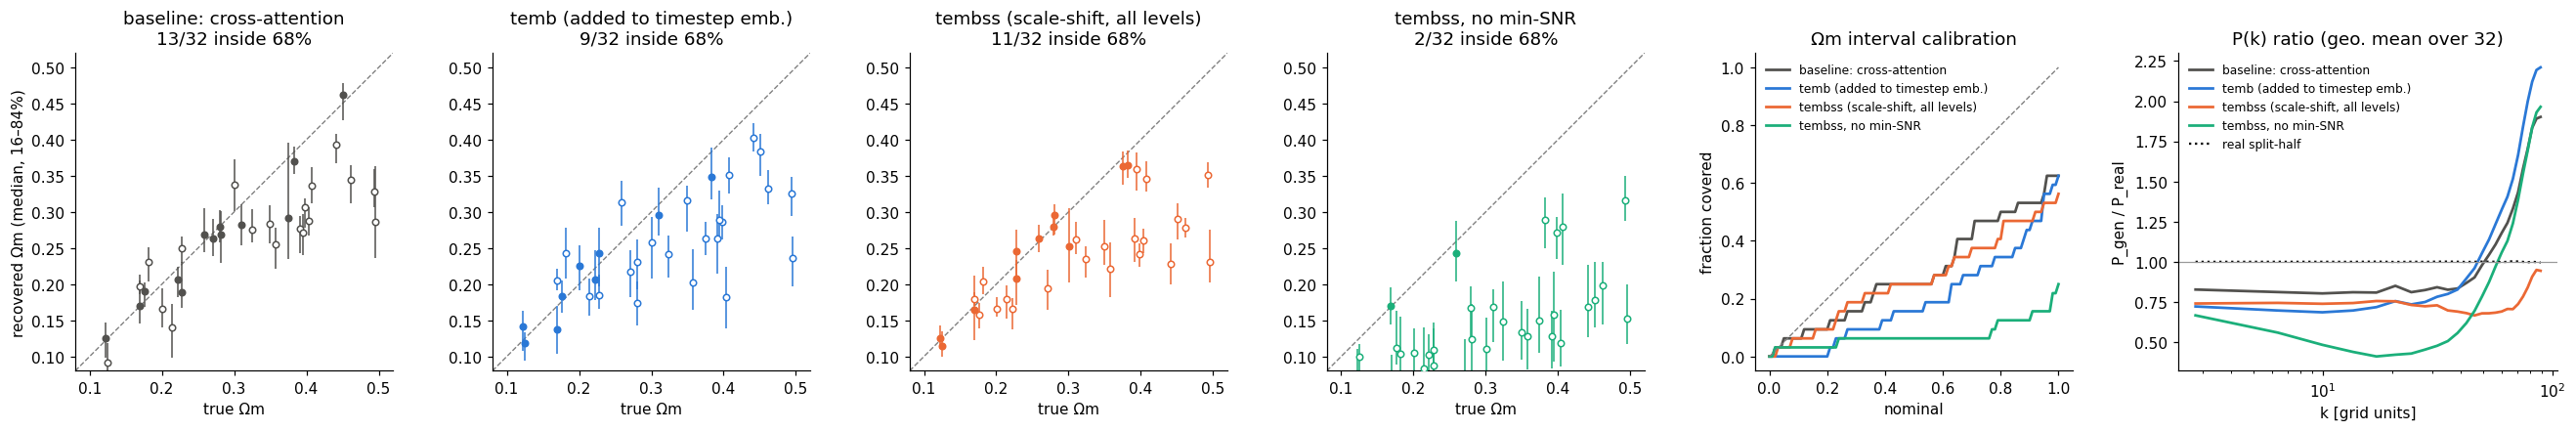

In [4]:
colors = dict(zip(cm.index, ["#52514e", "#2a78d6", "#eb6834", "#1baf7a"]))
fig, axes = plt.subplots(1, len(cm) + 2, figsize=(4.0 * (len(cm) + 2), 3.9), constrained_layout=True)
for ax, (label, pts) in zip(axes, pts_by.items()):
    g = pts[pts.parameter == "Omega_m"]
    y = g.theta_rec_median.to_numpy()
    cov = (g.theta_rec_q16 <= g.theta_in) & (g.theta_in <= g.theta_rec_q84)
    ax.plot([0.08, 0.52], [0.08, 0.52], "--", color="0.5", lw=0.9)
    ax.errorbar(g.theta_in, y, yerr=[y - g.theta_rec_q16, g.theta_rec_q84 - y], fmt="none", ecolor=colors[label], lw=1)
    ax.scatter(g.theta_in[cov], y[cov], s=18, color=colors[label], zorder=3)
    ax.scatter(g.theta_in[~cov], y[~cov], s=18, facecolor="white", edgecolor=colors[label], zorder=3)
    ax.set(xlim=(0.08, 0.52), ylim=(0.08, 0.52), aspect="equal", xlabel="true Ωm", title=f"{label}\n{int(cov.sum())}/32 inside 68%")
axes[0].set_ylabel("recovered Ωm (median, 16–84%)")
ax = axes[len(cm)]
for label, c in cov_curves.items():
    ax.plot(LEVELS, c["Omega_m"], color=colors[label], lw=1.8, label=label)
ax.plot([0, 1], [0, 1], "--", color="0.5", lw=0.9); ax.set(xlabel="nominal", ylabel="fraction covered", title="Ωm interval calibration", aspect="equal")
ax.legend(fontsize=8)
ax = axes[-1]
for label, r in pk_curves.items():
    ax.plot(BIN["kc"], np.exp(np.log(r).mean(0)), color=colors[label], lw=1.8, label=label)
ax.plot(BIN["kc"], np.exp(np.log(split_half).mean(0)), ":", color="k", label="real split-half")
ax.axhline(1, color="0.6", lw=0.8); ax.set(xscale="log", xlabel="k [grid units]", ylabel="P_gen / P_real", title="P(k) ratio (geo. mean over 32)")
ax.legend(fontsize=8)
plt.show()

## 2. Ωm-only label vs (Ωm, σ8) label

Both models use the **cross-attention** route from the table, the same training maps at each N and the same held-out set; only the
label in the token differs: **(Ωm, σ8)** (the continuous Ωm–σ8 model, the Section 1 baseline at N = 256) vs **Ωm only**.
The Ωm-only model is never told σ8, so only Ωm is scored for it.

**Predictions (ledger):** `nf_om_continuous_200k` had no quantitative prediction (expectation: Ωm-only does better for Ωm).
`nf_om_continuous_n1024_sample_eval` (written 2026-10-09 before sampling): Ωm-only N = 1024 has |median bias| < 0.25 W (< 0.0233)
**and** ≥ 16/32 inside 68%. Falsified if |bias| ≥ 0.25 W or ≤ 12/32.

In [5]:
OM = {r["dataset_size"]: r for r in json.loads((PROJECT_DIR / "local/nf_conditional_om_continuous_200k/manifest.json").read_text())}
OS = {r["dataset_size"]: r for r in json.loads((PROJECT_DIR / "local/nf_conditional_omsig_continuous_200k/manifest.json").read_text())}
rows, om_pts = [], {}
for n in (64, 256, 1024):
    for model, row, folder in [("Ωm-only", OM[n], "results/nf_conditional_om_continuous_200k/" + ("calibration_vgg_n1024" if n == 1024 else "calibration_vgg_n64_n256")),
                               ("(Ωm, σ8)", OS[n], "results/nf_conditional_omsig_continuous_200k/calibration_vgg")]:
        rec, pts, _ = recovery(folder, row["run_name"], params=("Omega_m",))
        ms, _ = map_stats(row["sample_path"].format(seed=123, k=64), row["prepared_image_path"])
        rows.append(dict(model=model, N=n, **rec, **ms))
        if model == "Ωm-only":
            om_pts[n] = pts
        src(f"{folder}/bias_probe_per_cosmology_points.csv [{row['run_name']}]")
lab = pd.DataFrame(rows)
cols = ["Omega_m_median_bias", "Omega_m_median_bias_over_W", "Omega_m_covered68", "Omega_m_covered95", "Omega_m_median_width68",
        "pk_large", "pk_mid", "pk_small", "nearest_train_cosine_median", "pix_std_ratio_median"]
display(lab.set_index(["N", "model"])[cols].round(4))
r = lab[(lab.model == "Ωm-only") & (lab.N == 1024)].iloc[0]
bias_ok, cov_ok = abs(r.Omega_m_median_bias) < 0.25 * W, r.Omega_m_covered68 >= 16
falsified = abs(r.Omega_m_median_bias) >= 0.25 * W or r.Omega_m_covered68 <= 12
verdict = "supported" if (bias_ok and cov_ok) else ("unsupported (falsified)" if falsified else "mixed")
print(f"N=1024 Ωm-only: median bias {r.Omega_m_median_bias:+.4f} ({r.Omega_m_median_bias_over_W:+.2f} W), "
      f"{int(r.Omega_m_covered68)}/32 inside 68%  ->  prediction {verdict}")

source: results/nf_conditional_om_continuous_200k/calibration_vgg_n64_n256/bias_probe_per_cosmology_points.csv [nf_cond_omc_hi_u128_d2p06_n64_fresh200k]
source: results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_cond_omsigc_hi_u128_d2p06_n64_fresh200k]
source: results/nf_conditional_om_continuous_200k/calibration_vgg_n64_n256/bias_probe_per_cosmology_points.csv [nf_cond_omc_hi_u128_d2p08_n256_fresh200k]
source: results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_cond_omsigc_hi_u128_d2p08_n256_fresh200k]
source: results/nf_conditional_om_continuous_200k/calibration_vgg_n1024/bias_probe_per_cosmology_points.csv [nf_cond_omc_hi_u128_d2p10_n1024_fresh200k]
source: results/nf_conditional_omsig_continuous_200k/calibration_vgg/bias_probe_per_cosmology_points.csv [nf_cond_omsigc_hi_u128_d2p10_n1024_fresh200k]


Omega_m_median_bias  Omega_m_median_bias_over_W  \
N    model                                                       
64   Ωm-only                0.0051                      0.0547   
     (Ωm, σ8)              -0.0480                     -0.5151   
256  Ωm-only               -0.0152                     -0.1635   
     (Ωm, σ8)              -0.0344                     -0.3694   
1024 Ωm-only               -0.0695                     -0.7460   
     (Ωm, σ8)              -0.0558                     -0.5990   

               Omega_m_covered68  Omega_m_covered95  Omega_m_median_width68  \
N    model                                                                    
64   Ωm-only                  11                 16                  0.0421   
     (Ωm, σ8)                  9                 12                  0.0385   
256  Ωm-only                  22                 30                  0.0994   
     (Ωm, σ8)                 13                 18                  0.0519   
1024 Ωm-only                  12                 18                  0.0829   
     (Ωm, σ8)                 10                 17                  0.0801   

               pk_large  pk_mid  pk_small  nearest_train_cosine_median  \
N    model                                                               
64   Ωm-only     0.9343  0.9690    0.9977                       0.9964   
     (Ωm, σ8)    0.7346  0.8049    0.8560                       0.9241   
256  Ωm-only     0.8793  0.9008    1.0679                       0.9869   
     (Ωm, σ8)    0.8198  0.8183    0.9449                       0.9512   
1024 Ωm-only     0.4832  0.5143    0.6812                       0.1841   
     (Ωm, σ8)    0.5068  0.5306    0.6589                       0.1928   

               pix_std_ratio_median  
N    model                           
64   Ωm-only                 0.9955  
     (Ωm, σ8)                0.8971  
256  Ωm-only                 0.9764  
     (Ωm, σ8)                0.9461  
1024 Ωm-only                 0.7495  
     (Ωm, σ8)                0.7623

N=1024 Ωm-only: median bias -0.0695 (-0.75 W), 12/32 inside 68%  ->  prediction unsupported (falsified)


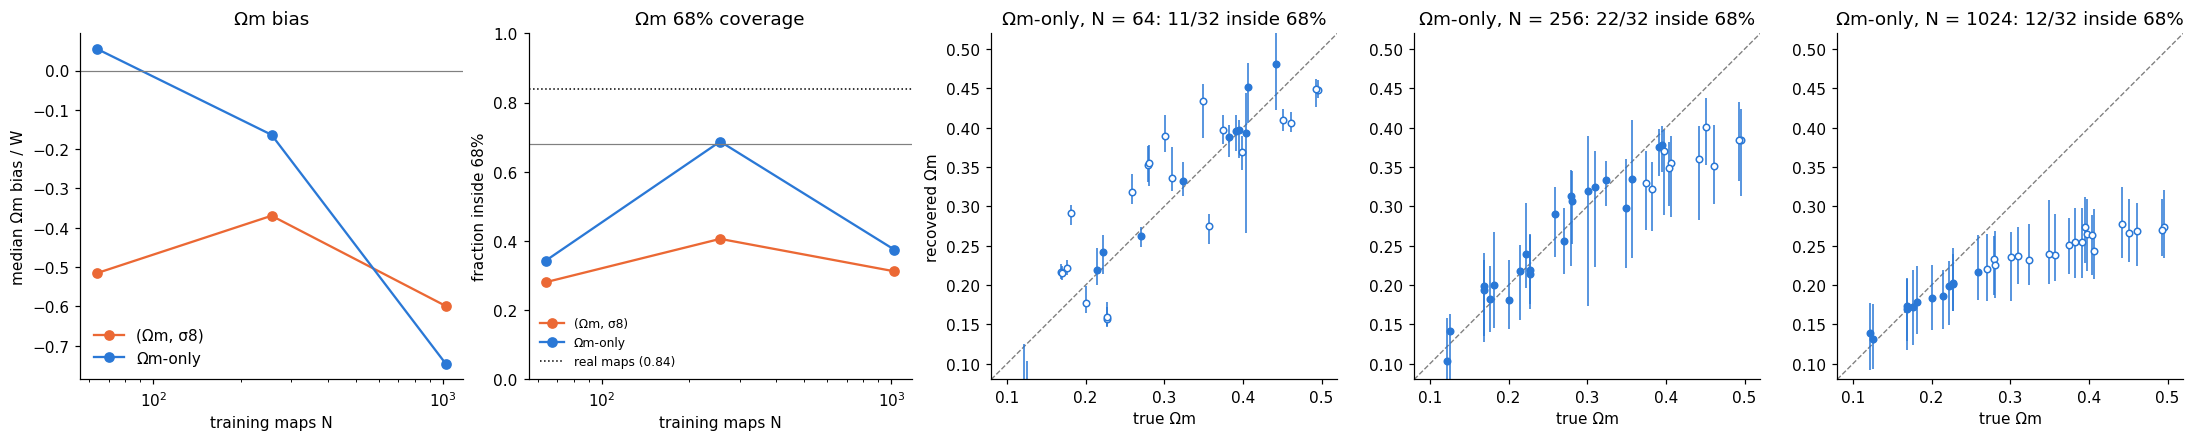

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.9), constrained_layout=True)
cmap = {"Ωm-only": "#2a78d6", "(Ωm, σ8)": "#eb6834"}
for model, g in lab.groupby("model"):
    axes[0].plot(g.N, g.Omega_m_median_bias_over_W, "o-", color=cmap[model], label=model)
    axes[1].plot(g.N, g.Omega_m_covered68 / 32, "o-", color=cmap[model], label=model)
axes[0].axhline(0, color="0.5", lw=0.8); axes[0].set(xscale="log", xlabel="training maps N", ylabel="median Ωm bias / W", title="Ωm bias")
axes[1].axhline(0.84, color="k", ls=":", lw=1, label="real maps (0.84)"); axes[1].axhline(0.68, color="0.5", lw=0.8)
axes[1].set(xscale="log", xlabel="training maps N", ylabel="fraction inside 68%", ylim=(0, 1), title="Ωm 68% coverage")
axes[0].legend(); axes[1].legend(fontsize=8)
for ax, n in zip(axes[2:], (64, 256, 1024)):
    g = om_pts[n][om_pts[n].parameter == "Omega_m"]
    y = g.theta_rec_median.to_numpy(); cov = (g.theta_rec_q16 <= g.theta_in) & (g.theta_in <= g.theta_rec_q84)
    ax.plot([0.08, 0.52], [0.08, 0.52], "--", color="0.5", lw=0.9)
    ax.errorbar(g.theta_in, y, yerr=[y - g.theta_rec_q16, g.theta_rec_q84 - y], fmt="none", ecolor=cmap["Ωm-only"], lw=1)
    ax.scatter(g.theta_in[cov], y[cov], s=18, color=cmap["Ωm-only"], zorder=3)
    ax.scatter(g.theta_in[~cov], y[~cov], s=18, facecolor="white", edgecolor=cmap["Ωm-only"], zorder=3)
    ax.set(xlim=(0.08, 0.52), ylim=(0.08, 0.52), aspect="equal", xlabel="true Ωm", title=f"Ωm-only, N = {n}: {int(cov.sum())}/32 inside 68%")
axes[2].set_ylabel("recovered Ωm")
plt.show()

## 3. Augmentation sweep (UNet-128; d4shift, d4equiv, warp vs noaug)

### 3a. Main result (already recorded: ledger `unet128_aug_sweep_eval`, verdict *unsupported*)

In [7]:
A = PROJECT_DIR / "results/unet128_aug_sweep"
m = json.loads((A / "evaluate_run_v1/metrics.json").read_text()); src(A / "evaluate_run_v1/metrics.json")
print("trusted:", m["trusted"], "|", m["note"])
display(pd.DataFrame(m["transition"])[["arm", "N_T", "sizes_scored"]])
main = pd.read_csv(A / "evaluate_run_v1/per_run.csv")
main = main[(main.status == "ok") & (main.dataset_size <= 2048)]
display(main.pivot_table(index="dataset_size", columns="arm", values=["G_d4", "orbit_copy_fraction", "pk_small"]).round(3))

source: /home/jiamingp/diffusion_models_repo/results/unet128_aug_sweep/evaluate_run_v1/metrics.json
trusted: True | regression checks passed


,arm,N_T,sizes_scored
0,d4equiv,64,"[64, 128, 256, 512, 1024, 2048]"
1,d4shift,64,"[64, 128, 256, 512, 1024, 2048]"
2,noaug,1024,"[64, 128, 256, 512, 1024, 2048, 4096, 8192, 16..."
3,warp,256,"[64, 128, 256, 512, 1024, 2048]"


G_d4                       orbit_copy_fraction                 \
arm          d4equiv d4shift  noaug   warp             d4equiv d4shift  noaug   
dataset_size                                                                    
64             0.842     1.0  0.000  0.000               0.150     0.0  1.000   
128            0.996     1.0  0.002  0.477               0.002     0.0  1.000   
256            1.000     1.0  0.092  0.939               0.000     0.0  0.973   
512            1.000     1.0  0.449  0.949               0.000     0.0  0.695   
1024           1.000     1.0  0.988  1.000               0.000     0.0  0.000   
2048           1.000     1.0  1.000  1.000               0.000     0.0  0.000   

                    pk_small                        
arm            warp  d4equiv d4shift  noaug   warp  
dataset_size                                        
64            0.066    1.124   0.867  1.060  0.565  
128           0.000    0.892   0.853  0.997  0.476  
256           0.000    0.684   0.909  0.958  0.443  
512           0.000    0.626   0.774  0.660  0.287  
1024          0.000    0.978   0.992  0.459  0.403  
2048          0.000    0.918   0.848  0.484  0.406

### 3b. Checkpoint sweep: does copying appear during training? (N = 64, 128; every 20k updates)

**Prediction (ledger, 2026-10-08 before sampling):** d4equiv N = 64 orbit copy fraction rises with training update (memorization delayed, not removed).
d4shift N = 64 and 128 copy fraction stays < 0.05 at every checkpoint and its orbit-NN median stays within 0.05 of the held-out real median.
Falsified if d4shift copy fraction exceeds 0.05 at any checkpoint, or d4equiv copy fraction does not increase from 20k to 200k.

source: /home/jiamingp/diffusion_models_repo/results/unet128_aug_sweep/evaluate_run_ckpt_v1/per_run.csv


arm          d4equiv        d4shift     
dataset_size     64     128     64   128
update_k                                
20             0.000  0.000     0.0  0.0
40             0.000  0.000     0.0  0.0
60             0.002  0.000     0.0  0.0
80             0.027  0.000     0.0  0.0
100            0.061  0.000     0.0  0.0
120            0.076  0.000     0.0  0.0
140            0.121  0.002     0.0  0.0
160            0.129  0.002     0.0  0.0
180            0.152  0.002     0.0  0.0
200            0.150  0.002     0.0  0.0

d4shift: max copy fraction 0.000, max |orbit-NN median - held-out median| 0.010 -> part 1 holds
d4equiv N=64: copy fraction 0.000 at 20k -> 0.150 at 200k -> part 2 holds
prediction: supported


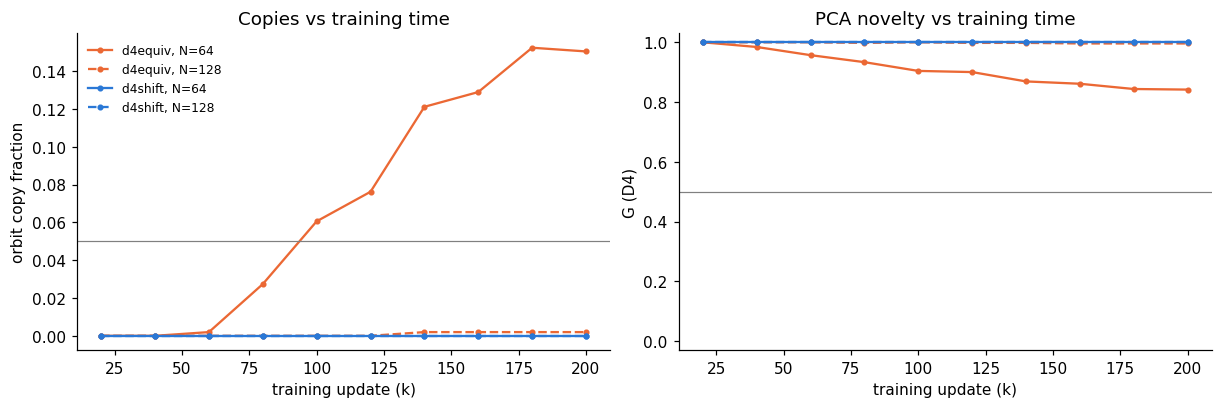

In [8]:
ck = pd.read_csv(A / "evaluate_run_ckpt_v1/per_run.csv"); src(A / "evaluate_run_ckpt_v1/per_run.csv")
ck = ck[ck.status == "ok"].copy()
ck["update_k"] = ck.run_name.str.extract(r"_u(\d+)k$").astype(int)
ck["heldout_orbit_nn_median"] = [float(np.median(np.load(A / "evaluate_run_ckpt_v1" / f"{r}_per_sample.npz")["heldout_orbit_nn"]))
                                 for r in ck.run_name]
display(ck.pivot_table(index="update_k", columns=["arm", "dataset_size"], values="orbit_copy_fraction").round(3))
s = ck[ck.arm == "d4shift"]
p1 = bool((s.orbit_copy_fraction < 0.05).all()) and bool((abs(s.orbit_nn_median - s.heldout_orbit_nn_median) <= 0.05).all())
e = ck[(ck.arm == "d4equiv") & (ck.dataset_size == 64)].sort_values("update_k")
p2 = bool(e.orbit_copy_fraction.iloc[-1] > e.orbit_copy_fraction.iloc[0])
print(f"d4shift: max copy fraction {s.orbit_copy_fraction.max():.3f}, max |orbit-NN median - held-out median| "
      f"{abs(s.orbit_nn_median - s.heldout_orbit_nn_median).max():.3f} -> part 1 {'holds' if p1 else 'FAILS'}")
print(f"d4equiv N=64: copy fraction {e.orbit_copy_fraction.iloc[0]:.3f} at {e.update_k.iloc[0]}k -> "
      f"{e.orbit_copy_fraction.iloc[-1]:.3f} at {e.update_k.iloc[-1]}k -> part 2 {'holds' if p2 else 'FAILS'}")
print("prediction:", "supported" if p1 and p2 else ("unsupported" if not (p1 or p2) else "mixed"))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for (arm, n), g in ck.groupby(["arm", "dataset_size"]):
    g = g.sort_values("update_k")
    ls = "-" if n == 64 else "--"
    c = "#2a78d6" if arm == "d4shift" else "#eb6834"
    axes[0].plot(g.update_k, g.orbit_copy_fraction, ls, marker="o", ms=3, color=c, label=f"{arm}, N={n}")
    axes[1].plot(g.update_k, g.G_d4, ls, marker="o", ms=3, color=c, label=f"{arm}, N={n}")
axes[0].axhline(0.05, color="0.5", lw=0.8); axes[0].set(xlabel="training update (k)", ylabel="orbit copy fraction", title="Copies vs training time")
axes[1].axhline(0.5, color="0.5", lw=0.8); axes[1].set(xlabel="training update (k)", ylabel="G (D4)", ylim=(-0.03, 1.03), title="PCA novelty vs training time")
axes[0].legend(fontsize=8); plt.show()

### 3c. Patch mosaic: are d4shift samples stitched from training patches?

`patch{p}_excess` = median best-match cosine of generated p×p patches to any training patch (all shifts and D4 elements)
minus the same for held-out real patches; map-bootstrap 95% CI.

**Prediction (ledger, 2026-10-08 before any code):** (1) sanity: noaug N = 64 excess > 0 at every p and patch-64 copy fraction ≥ 0.9.
(2) d4shift N = 64: excess > 0 (CI excludes 0) at p = 8 and 16; CI includes 0 or excess < 0 at p = 64.
(3) d4shift excess at p = 16 decreases monotonically from N = 64 to 1024.

source: /home/jiamingp/diffusion_models_repo/results/unet128_aug_sweep/patch_mosaic_v1/per_run.csv


patch8_excess  patch16_excess  patch32_excess  \
arm     dataset_size                                                  
d4equiv 64                  -0.0487          0.0722          0.2662   
        128                 -0.0661         -0.0162          0.1320   
        256                 -0.0319         -0.0234          0.0172   
        1024                 0.0032         -0.0065         -0.0136   
d4shift 64                   0.0010         -0.0025         -0.0020   
        128                  0.0083          0.0055          0.0060   
        256                  0.0113          0.0031          0.0082   
        1024                 0.0074          0.0001         -0.0027   
noaug   64                   0.0581          0.2044          0.4212   
        128                  0.0590          0.2053          0.4253   
        256                  0.0497          0.1951          0.4196   
        1024                -0.0259          0.0004          0.0922   
warp    64                   0.0048          0.0303          0.0887   
        128                  0.0100          0.0274          0.0862   
        256                  0.0101          0.0196          0.0706   
        1024                 0.0003         -0.0034          0.0052   

                      patch64_excess  
arm     dataset_size                  
d4equiv 64                    0.3133  
        128                   0.1936  
        256                   0.0354  
        1024                 -0.0152  
d4shift 64                    0.0015  
        128                   0.0087  
        256                   0.0123  
        1024                 -0.0034  
noaug   64                    0.6394  
        128                   0.6361  
        256                   0.6348  
        1024                  0.2534  
warp    64                    0.2934  
        128                   0.2921  
        256                   0.2657  
        1024                  0.0846

(1) sanity, noaug N=64: holds
(2) d4shift N=64 small-p excess, no p=64 excess: FAILS
(3) d4shift p=16 excess falls with N: FAILS
d4shift N=64 CIs: {8: (-0.0044, 0.0071), 16: (-0.014, 0.006), 32: (-0.0111, 0.0084), 64: (-0.0096, 0.0123)}
d4shift p=16 excess by N: {64: -0.0025, 128: 0.0055, 256: 0.0031, 1024: 0.0001}


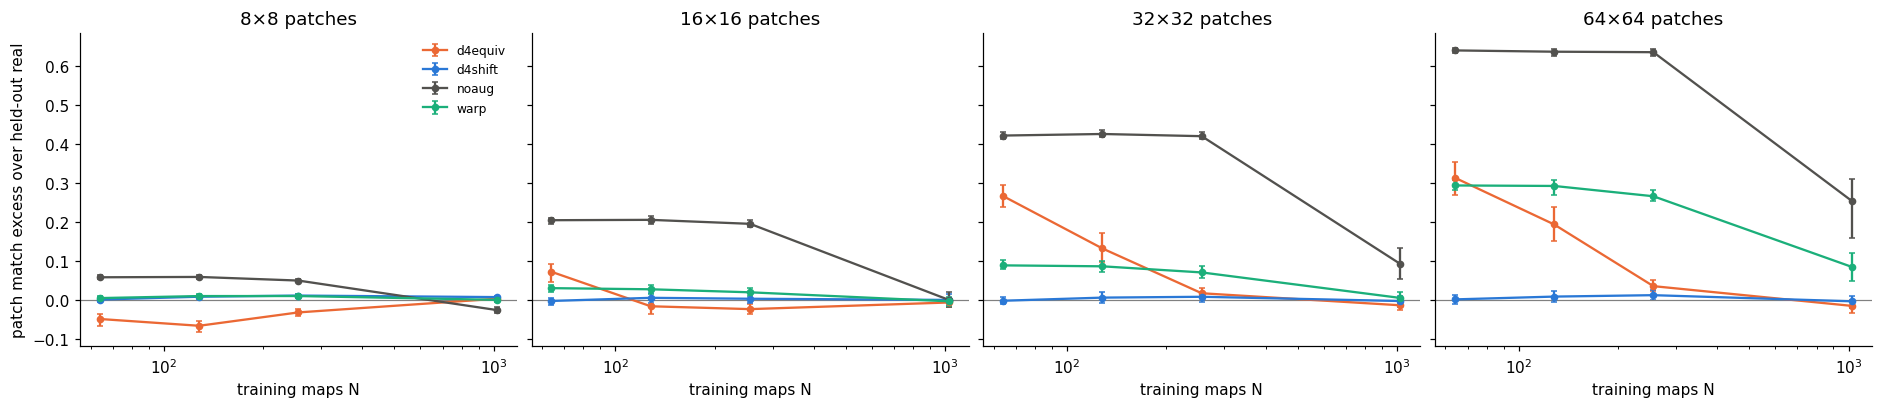

In [9]:
pm = pd.read_csv(A / "patch_mosaic_v1/per_run.csv"); src(A / "patch_mosaic_v1/per_run.csv")
pm = pm[pm.status == "ok"]
P = (8, 16, 32, 64)
tbl = pm.set_index(["arm", "dataset_size"])[[f"patch{p}_excess" for p in P]].sort_index()
display(tbl.round(4))
def ci(row, p): return row[f"patch{p}_excess_ci_low"], row[f"patch{p}_excess_ci_high"]
na = pm[(pm.arm == "noaug") & (pm.dataset_size == 64)].iloc[0]
c1 = all(na[f"patch{p}_excess"] > 0 for p in P) and na["patch64_copy_fraction"] >= 0.9
ds = pm[(pm.arm == "d4shift") & (pm.dataset_size == 64)].iloc[0]
c2 = all(ci(ds, p)[0] > 0 for p in (8, 16)) and (ci(ds, 64)[0] <= 0 or ds["patch64_excess"] < 0)
seq = pm[pm.arm == "d4shift"].sort_values("dataset_size")["patch16_excess"].to_numpy()
c3 = bool(np.all(np.diff(seq) < 0))
for name, ok in [("(1) sanity, noaug N=64", c1), ("(2) d4shift N=64 small-p excess, no p=64 excess", c2), ("(3) d4shift p=16 excess falls with N", c3)]:
    print(f"{name}: {'holds' if ok else 'FAILS'}")
print("d4shift N=64 CIs:", {p: tuple(round(v, 4) for v in ci(ds, p)) for p in P})
print("d4shift p=16 excess by N:", dict(zip(pm[pm.arm == "d4shift"].sort_values("dataset_size").dataset_size, np.round(seq, 4))))
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6), constrained_layout=True, sharey=True)
ac = {"noaug": "#52514e", "d4shift": "#2a78d6", "d4equiv": "#eb6834", "warp": "#1baf7a"}
for ax, p in zip(axes, P):
    for arm, g in pm.groupby("arm"):
        g = g.sort_values("dataset_size")
        ax.errorbar(g.dataset_size, g[f"patch{p}_excess"], yerr=[g[f"patch{p}_excess"] - g[f"patch{p}_excess_ci_low"],
                    g[f"patch{p}_excess_ci_high"] - g[f"patch{p}_excess"]], marker="o", ms=4, color=ac[arm], label=arm, capsize=2)
    ax.axhline(0, color="0.5", lw=0.8); ax.set(xscale="log", xlabel="training maps N", title=f"{p}×{p} patches")
axes[0].set_ylabel("patch match excess over held-out real"); axes[0].legend(fontsize=8); plt.show()

## Summary (numbers from the cells above; one training seed per run; wording checked by the critic agent 2026-10-09)

**1. Conditioning mechanism, N = 256: no model met the adoption rule; the prediction is not supported.**
- temb and tembss match the cross-attention baseline (the continuous (Ωm, σ8) model) on Ωm bias and coverage within single-seed noise:
  bias −0.042 and −0.041 vs −0.034; 9/32 and 11/32 vs 13/32 inside the 68% interval.
- Both lose large- and mid-scale power: P(k) 0.71–0.75 vs 0.82. tembss also loses small-scale power (0.70 vs 0.94).
  temb's small-scale band is slightly closer to 1 (0.97).
- tembss without min-SNR is clearly worse: bias −0.141, 2/32, bands 0.61 / 0.44 / 0.68.
  Its σ8 coverage is higher (10/32 vs 6/32 for tembss), so it is not worse on every metric.
- The pixel-std ratio to the nearest training map fell (0.89 / 0.89 / 0.74 vs 0.95), the opposite of the predicted rise to ≥ 0.98.
- The new models also drop the cross-attention transformer blocks (see the caveat above), so the label route is not isolated.

**2. Ωm-only label vs (Ωm, σ8) label (both cross-attention).**
- At N ≤ 256 the Ωm-only model makes closer copies (nearest-training cosine 0.996 / 0.987 vs 0.924 / 0.951). The copied maps
  have the right Ωm, but their σ8 is not matched, because the model is never told σ8.
- Its Ωm bias is smaller at N = 64 (+0.005 vs −0.048). At N = 256 its coverage is higher (22 vs 13/32), but its intervals are about
  twice as wide (0.099 vs 0.052), and the bias difference (−0.015 vs −0.034) is within single-seed noise.
- At N = 1024 the two labels do not differ (−0.070 vs −0.056; 12 vs 10/32). The pre-registered N = 1024 prediction is falsified.
  Large- and mid-scale P(k) is 0.48–0.53 for both (small scales 0.66–0.68). Most samples are not copies there. Cause untested.
- Not yet done: per map, regress recovered Ωm on the σ8 of the copied training map. This would separate "better label" from
  "wider spread across σ8" (CPU, existing files).

**3. Augmentation sweep.**
- Main result (ledger `unet128_aug_sweep_eval`, unsupported): d4shift and d4equiv are not memorized at any N, including 64;
  no-aug crosses at N = 1024.
- Checkpoint sweep (prediction supported as written): d4shift has copy fraction 0.000 at every checkpoint (N = 64, 128).
  d4equiv N = 64 rises from 0 to 0.15 by 180k updates and is then flat (0.152 → 0.150). Its G(D4) stays 0.84, so it remains
  below the project's "memorized" threshold. Whether it gets there with longer training is being tested (`unet128_aug_cont400k`).
- Patch mosaic (prediction falsified): d4shift N = 64 shows no patch excess at any patch size (all four 95% CIs include 0).
  Large-patch excess also appears in models that are not copying (d4equiv N = 128, noaug N = 1024), so it does not by itself
  measure copying.

All six ledger results for these runs were recorded 2026-10-09 (`experiments/ledger.jsonl`). Some of their notes use the earlier,
stronger wording; this summary is the corrected version.